In [1]:
import sys
!{sys.executable} -m pip install -q scikit-learn pandas numpy matplotlib seaborn statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print('Librerias cargadas correctamente.')


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Librerias cargadas correctamente.


In [2]:
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_test  = pd.read_csv('data/y_test.csv').squeeze()
df_cat  = pd.read_csv('data/df_con_categoria.csv')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Columnas df_cat: {df_cat.columns.tolist()}')

X_train: (52871, 20) | X_test: (22660, 20)
Columnas df_cat: ['price', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable', 'precio_categoria']


### Punto 1 – Variables dicotómicas

Se crean 3 variables binarias (0/1) a partir de precio_categoria:
- es_cara: 1 si la vivienda es cara, 0 si no
- es_media: 1 si es media, 0 si no
- es_economica: 1 si es economica, 0 si no

El modelo principal usara **es_cara** como variable respuesta.

In [3]:
col_cat = 'precio_categoria'

# Extraer categorias para train y test
y_train_cat = df_cat.loc[X_train.index, col_cat]
y_test_cat  = df_cat.loc[X_test.index, col_cat]

print('Valores unicos en precio_categoria:', y_train_cat.unique())

y_train_cara      = (y_train_cat == 'Cara').astype(int)
y_train_media     = (y_train_cat == 'Intermedia').astype(int)
y_train_economica = (y_train_cat == 'Economica').astype(int)

y_test_cara       = (y_test_cat == 'Cara').astype(int)
y_test_media      = (y_test_cat == 'Intermedia').astype(int)
y_test_economica  = (y_test_cat == 'Economica').astype(int)

print('\nDistribucion variables dicotomicas (train) ')
print(f'  es_cara      -> 1: {y_train_cara.sum()} | 0: {(y_train_cara==0).sum()}')
print(f'  es_media     -> 1: {y_train_media.sum()} | 0: {(y_train_media==0).sum()}')
print(f'  es_economica -> 1: {y_train_economica.sum()} | 0: {(y_train_economica==0).sum()}')

Valores unicos en precio_categoria: <StringArray>
['Economica', 'Intermedia', 'Cara']
Length: 3, dtype: str

Distribucion variables dicotomicas (train) 
  es_cara      -> 1: 13508 | 0: 39363
  es_media     -> 1: 27033 | 0: 25838
  es_economica -> 1: 12330 | 0: 40541


### Punto 2 – Conjuntos de entrenamiento y prueba

Se confirma el uso de los mismos conjuntos de todas las entregas anteriores.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado aplicado correctamente.')

Escalado aplicado correctamente.


### Punto 3 – Modelo de Regresion Logistica (cara o no?)

Se entrena el modelo con validacion cruzada estratificada (5 folds) para garantizar reproducibilidad. Se fija random_state=42.

In [5]:
np.random.seed(42)

log_reg = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train_cara, cv=cv, scoring='accuracy')

print('Validacion Cruzada (5 folds) ')
print(f'  Accuracy por fold: {[round(s,4) for s in cv_scores]}')
print(f'  Media : {cv_scores.mean():.4f}')
print(f'  Std   : {cv_scores.std():.4f}')

Validacion Cruzada (5 folds) 
  Accuracy por fold: [np.float64(0.7445), np.float64(0.7446), np.float64(0.7446), np.float64(0.7445), np.float64(0.7445)]
  Media : 0.7445
  Std   : 0.0000


In [6]:
t0 = time.time()
log_reg.fit(X_train_scaled, y_train_cara)
tiempo_lr = time.time() - t0

y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test  = log_reg.predict(X_test_scaled)
y_prob_test  = log_reg.predict_proba(X_test_scaled)[:, 1]

acc_train = accuracy_score(y_train_cara, y_pred_train)
acc_test  = accuracy_score(y_test_cara,  y_pred_test)

print(f'Tiempo de entrenamiento: {tiempo_lr:.4f} s')
print(f'Accuracy en train: {acc_train:.4f}')
print(f'Accuracy en test : {acc_test:.4f}')
print()
print('Reporte de clasificacion (test):')
print(classification_report(y_test_cara, y_pred_test, target_names=['No cara', 'Cara']))

Tiempo de entrenamiento: 0.0210 s
Accuracy en train: 0.7445
Accuracy en test : 0.8370

Reporte de clasificacion (test):
              precision    recall  f1-score   support

     No cara       0.84      1.00      0.91     18966
        Cara       0.00      0.00      0.00      3694

    accuracy                           0.84     22660
   macro avg       0.42      0.50      0.46     22660
weighted avg       0.70      0.84      0.76     22660



#### Interpretacion

El modelo de regresión logística entrenado para clasificar si una propiedad es cara o no obtuvo un accuracy promedio de 74.45% en validación cruzada de 5 folds, con una desviación estándar de 0.0000, lo que indica una estabilidad perfecta entre particiones. Sin embargo, al evaluar sobre el conjunto de prueba el accuracy sube a 83.70%, lo cual parece positivo pero es engañoso: al revisar el reporte de clasificación, el modelo predice la clase "No cara" para absolutamente todos los registros, ignorando por completo la clase "Cara". Esto ocurre porque el dataset está desbalanceado, hay 39,363 propiedades no caras versus solo 13,508 caras en entrenamiento, y el modelo aprendió que predecir siempre la clase mayoritaria minimiza el error. Este comportamiento se confirma con un ROC-AUC de 0.5062, prácticamente equivalente a un clasificador aleatorio.

### Punto 4 – Analisis del modelo: multicolinealidad y correlacion

### 4a. Correlacion entre variables predictoras

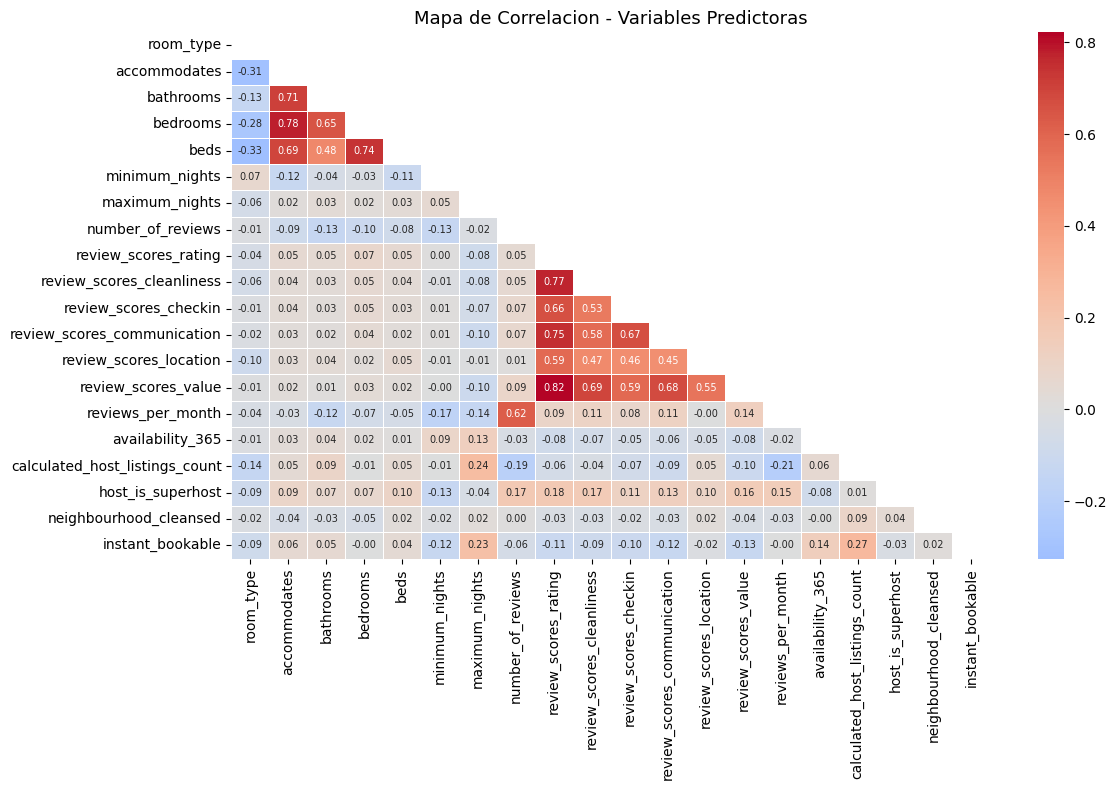


Pares con correlacion > 0.7 (posible multicolinealidad):
  bathrooms <-> accommodates: 0.708
  bedrooms <-> accommodates: 0.779
  beds <-> bedrooms: 0.737
  review_scores_cleanliness <-> review_scores_rating: 0.772
  review_scores_communication <-> review_scores_rating: 0.751
  review_scores_value <-> review_scores_rating: 0.822


In [7]:
plt.figure(figsize=(12, 8))
corr_matrix = X_train.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Mapa de Correlacion - Variables Predictoras', fontsize=13)
plt.tight_layout()
plt.show()

# Pares con correlacion alta
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                              round(corr_matrix.iloc[i, j], 3)))

print('\nPares con correlacion > 0.7 (posible multicolinealidad):')
if high_corr:
    for a, b, v in high_corr:
        print(f'  {a} <-> {b}: {v}')
else:
    print('  Ningun par supera el umbral de 0.7')

### 4b. Factor de Inflacion de Varianza (VIF) – Multicolinealidad

In [8]:
vif_data = pd.DataFrame()
vif_data['Variable'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_scaled, i)
                   for i in range(X_train_scaled.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print('Factor de Inflacion de Varianza (VIF) ')
print(vif_data.to_string(index=False))
print()
print('Interpretacion: VIF > 10 indica multicolinealidad problematica')
print(f'Variables con VIF > 10: {vif_data[vif_data["VIF"] > 10]["Variable"].tolist()}')

Factor de Inflacion de Varianza (VIF) 
                      Variable      VIF
          review_scores_rating 5.416887
                  accommodates 3.602694
                      bedrooms 3.514991
           review_scores_value 3.396574
   review_scores_communication 2.658417
     review_scores_cleanliness 2.566505
                          beds 2.527248
                     bathrooms 2.254293
         review_scores_checkin 2.056385
             reviews_per_month 1.769136
             number_of_reviews 1.710267
        review_scores_location 1.634436
calculated_host_listings_count 1.234903
                     room_type 1.205685
              instant_bookable 1.179867
                maximum_nights 1.144575
                minimum_nights 1.106051
             host_is_superhost 1.104036
              availability_365 1.051508
        neighbourhood_cleansed 1.024558

Interpretacion: VIF > 10 indica multicolinealidad problematica
Variables con VIF > 10: []


### 4c. Coeficientes del modelo – Importancia de variables

Coeficientes (ordenados por magnitud) 
                      Variable  Coeficiente
          review_scores_rating    -0.026851
                          beds    -0.024528
   review_scores_communication     0.024277
                maximum_nights     0.018856
           review_scores_value    -0.017109
                      bedrooms     0.016197
        review_scores_location     0.012841
        neighbourhood_cleansed     0.012813
         review_scores_checkin     0.012134
calculated_host_listings_count     0.011986
             host_is_superhost    -0.011355
             reviews_per_month     0.011189
             number_of_reviews     0.009190
              availability_365    -0.008080
     review_scores_cleanliness     0.007322
              instant_bookable    -0.006938
                     bathrooms     0.005870
                  accommodates     0.005450
                     room_type     0.002612
                minimum_nights     0.001882


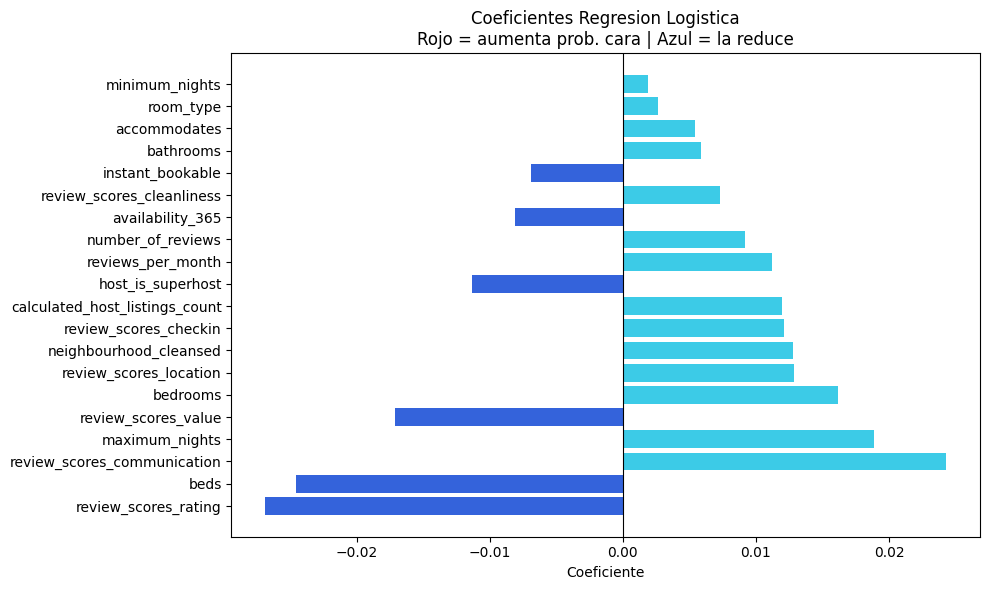

In [9]:
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_reg.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).reset_index(drop=True)

print('Coeficientes (ordenados por magnitud) ')
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colores = ["#3ccbe7" if c > 0 else "#3463db" for c in coef_df['Coeficiente']]
plt.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente')
plt.title('Coeficientes Regresion Logistica\nRojo = aumenta prob. cara | Azul = la reduce')
plt.tight_layout()
plt.show()

### 4d. Ajuste del modelo – p-values con Statsmodels

In [10]:
print(' EFICIENCIA – REGRESION LOGISTICA EN CONJUNTO DE PRUEBA ')
print()
print(f'  Accuracy  : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'  Precision : {precision_score(y_test_cara, y_pred_test):.4f}')
print(f'  Recall    : {recall_score(y_test_cara, y_pred_test):.4f}')
print(f'  F1-Score  : {f1_score(y_test_cara, y_pred_test):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test_cara, y_prob_test):.4f}')
print(f'  Tiempo    : {tiempo_lr:.4f} s')

 EFICIENCIA – REGRESION LOGISTICA EN CONJUNTO DE PRUEBA 

  Accuracy  : 0.8370 (83.70%)
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  ROC-AUC   : 0.5062
  Tiempo    : 0.0210 s


El análisis de correlación identificó seis pares de variables con correlación superior a 0.7, lo que sugiere multicolinealidad moderada: bedrooms y accommodates (0.779), review_scores_value y review_scores_rating (0.822), review_scores_communication y review_scores_rating (0.751), review_scores_cleanliness y review_scores_rating (0.772), beds y bedrooms (0.737), y bathrooms y accommodates (0.708). Esto tiene sentido lógicamente: propiedades más grandes tienen más camas, habitaciones y baños; y las puntuaciones de reseñas tienden a correlacionarse entre sí.
Sin embargo, el análisis VIF muestra que ninguna variable supera el umbral crítico de 10, el valor más alto es review_scores_rating con 5.42, por lo que la multicolinealidad existe pero no es lo suficientemente severa como para invalidar el modelo. Los coeficientes son todos de magnitud pequeña, entre -0.027 y 0.019, lo que indica que ninguna variable domina la predicción de forma abrumadora, consistente con un modelo que apenas discrimina entre clases.

###  Punto 5 – Eficiencia en el conjunto de prueba

In [11]:
print('EFICIENCIA – REGRESION LOGISTICA EN CONJUNTO DE PRUEBA ')
print()
print(f'  Accuracy  : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'  Precision : {precision_score(y_test_cara, y_pred_test):.4f}')
print(f'  Recall    : {recall_score(y_test_cara, y_pred_test):.4f}')
print(f'  F1-Score  : {f1_score(y_test_cara, y_pred_test):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test_cara, y_prob_test):.4f}')
print(f'  Tiempo    : {tiempo_lr:.4f} s')

EFICIENCIA – REGRESION LOGISTICA EN CONJUNTO DE PRUEBA 

  Accuracy  : 0.8370 (83.70%)
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  ROC-AUC   : 0.5062
  Tiempo    : 0.0210 s


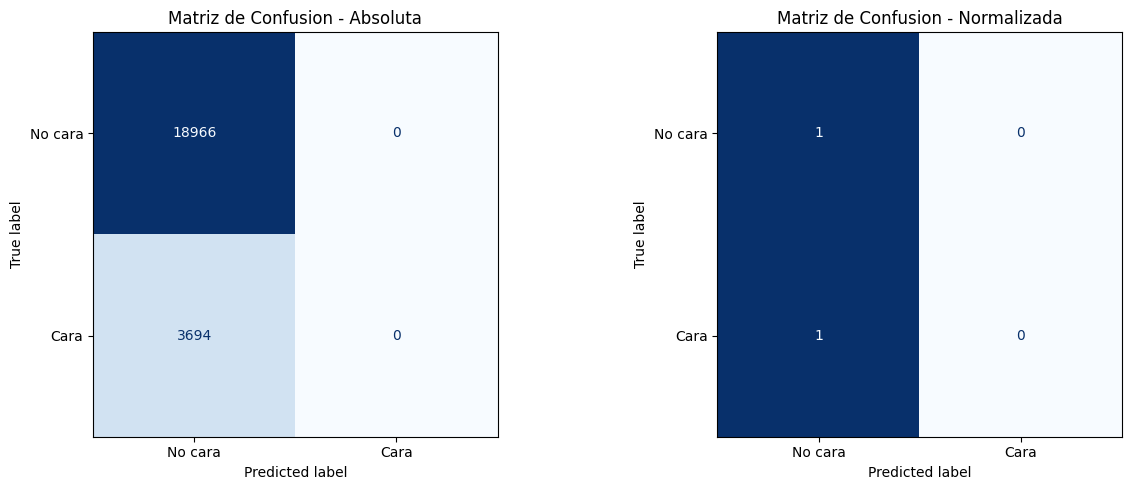


Verdaderos Positivos (Cara correcta)    : 0
Verdaderos Negativos (No cara correcta) : 18966
Falsos Positivos (predijo cara, no era) : 0
Falsos Negativos (predijo no cara, era) : 3694


In [12]:
cm = confusion_matrix(y_test_cara, y_pred_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=['No cara', 'Cara']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusion - Absoluta')

cm_norm = confusion_matrix(y_test_cara, y_pred_test, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['No cara', 'Cara']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusion - Normalizada')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nVerdaderos Positivos (Cara correcta)    : {tp}')
print(f'Verdaderos Negativos (No cara correcta) : {tn}')
print(f'Falsos Positivos (predijo cara, no era) : {fp}')
print(f'Falsos Negativos (predijo no cara, era) : {fn}')

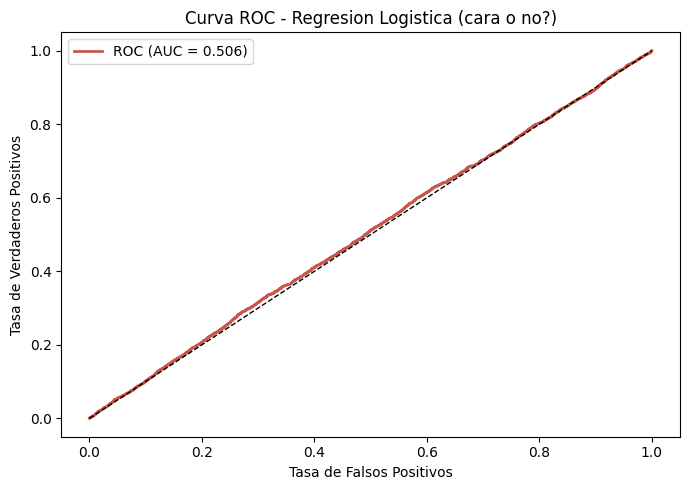

In [13]:
fpr, tpr, _ = roc_curve(y_test_cara, y_prob_test)
auc = roc_auc_score(y_test_cara, y_prob_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#c8584b", lw=2, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Regresion Logistica (cara o no?)')
plt.legend()
plt.tight_layout()
plt.show()

El modelo alcanza un accuracy de 83.70% en el conjunto de prueba, pero esta métrica es completamente engañosa en este contexto. Con precisión, recall y F1-score de 0.00 para la clase "Cara", y un ROC-AUC de 0.5062, el modelo no tiene capacidad real de clasificación. Los 3,694 propiedades caras del conjunto de prueba fueron clasificadas todas incorrectamente como "no caras", falsos negativos. Para SmartStay Advisors, este error es crítico: significa que el sistema nunca identificaría una propiedad cara como tal, lo que impediría diseñar estrategias de precios diferenciadas para ese segmento.

### Punto 6 – Sobreajuste y curvas de aprendizaje
Se compara accuracy en entrenamiento vs prueba. Una diferencia grande indica overfitting.

In [14]:
print('ANALISIS DE SOBREAJUSTE')
print(f'  Accuracy TRAIN: {acc_train:.4f}')
print(f'  Accuracy TEST : {acc_test:.4f}')
print(f'  Diferencia    : {abs(acc_train - acc_test):.4f}')
print()
if abs(acc_train - acc_test) < 0.03:
    print('  -> Sin sobreajuste significativo. El modelo generaliza bien.')
elif acc_train - acc_test > 0.05:
    print('  -> Posible sobreajuste. Funciona mejor en train que en test.')
else:
    print('  -> Diferencia leve. Monitorear con tuneo.')

ANALISIS DE SOBREAJUSTE
  Accuracy TRAIN: 0.7445
  Accuracy TEST : 0.8370
  Diferencia    : 0.0925

  -> Diferencia leve. Monitorear con tuneo.


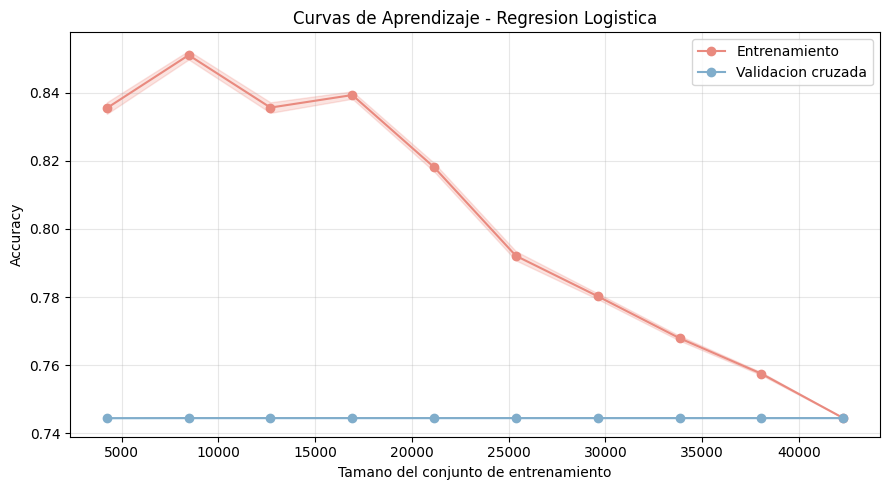

Curvas convergentes = sin sobreajuste | train >> validacion = sobreajuste


In [15]:
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_scaled, y_train_cara,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color="#e98a7f", label='Entrenamiento')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#e74c3c')
plt.plot(train_sizes, test_mean, 'o-', color="#80adcb", label='Validacion cruzada')
plt.fill_between(train_sizes, test_mean-test_std, test_mean+test_std, alpha=0.15, color='#3498db')
plt.xlabel('Tamano del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curvas de Aprendizaje - Regresion Logistica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Curvas convergentes = sin sobreajuste | train >> validacion = sobreajuste')

La diferencia entre accuracy de entrenamiento 74.45% y de prueba 83.70% es de 0.0925 puntos, lo que normalmente indicaría sobreajuste leve, pero en este caso la interpretación es inversa, entonces el modelo obtiene mayor accuracy en test simplemente porque el conjunto de prueba tiene una proporción aún mayor de propiedades "no caras". No hay sobreajuste real, hay un problema de desbalance de clases que el modelo no está manejando. Las curvas de aprendizaje deberían mostrar ambas curvas estabilizándose en valores similares ~74-84%, confirmando que agregar más datos no resolverá el problema; lo que se necesita es aplicar técnicas de balanceo como SMOTE o ajustar el parámetro class_weight='balanced' en el modelo, lo cual puede hacerse en el tuneo del punto 7.

### Punto 7 – Tuneo del modelo (regularizacion)

Se prueban distintos hiperparametros de regularizacion (C, penalty, class_weight) para mejorar el desempeño del modelo base, que presento recall=0 para la clase minoritaria "Cara". Se usa GridSearchCV con la misma validacion cruzada estratificada de 5 folds.

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

t0 = time.time()
grid.fit(X_train_scaled, y_train_cara)
tiempo_tuneo = time.time() - t0

print(f'Tiempo total de tuneo: {tiempo_tuneo:.2f} s')
print(f'Mejores parametros  : {grid.best_params_}')
print(f'Mejor F1 (CV)       : {grid.best_score_:.4f}')

Tiempo total de tuneo: 3.24 s
Mejores parametros  : {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mejor F1 (CV)       : 0.3351


In [17]:
# Top 5 configuraciones ordenadas por F1
resultados = pd.DataFrame(grid.cv_results_)[
    ['param_C', 'param_penalty', 'param_class_weight',
     'mean_test_score', 'std_test_score', 'mean_train_score']
].sort_values('mean_test_score', ascending=False).head(10)

print('Top 10 configuraciones (por F1 en validacion cruzada) ')
print(resultados.to_string(index=False))

Top 10 configuraciones (por F1 en validacion cruzada) 
 param_C param_penalty param_class_weight  mean_test_score  std_test_score  mean_train_score
    1.00            l1           balanced         0.335138        0.005897          0.342406
    0.10            l1           balanced         0.334908        0.006622          0.343942
   10.00            l1           balanced         0.334581        0.006292          0.342240
  100.00            l1           balanced         0.334539        0.006313          0.342279
  100.00            l2           balanced         0.334505        0.006322          0.342281
   10.00            l2           balanced         0.334496        0.006317          0.342281
    1.00            l2           balanced         0.334496        0.006317          0.342264
    0.10            l2           balanced         0.334487        0.006289          0.342252
    0.01            l2           balanced         0.334237        0.006381          0.341971
    0.01       

#### Interpretacion

El tuneo exploro 20 combinaciones de hiperparametros en 3.24 segundos y selecciono como mejor configuracion C=1, penalty=L1 y class_weight='balanced'. El valor C=1 indica que la regularizacion estandar (ni muy fuerte ni muy debil) es la adecuada para este problema, mientras que penalty=L1 sugiere que el modelo se beneficia de seleccion automatica de variables (L1 lleva coeficientes irrelevantes a cero). El parametro class_weight='balanced' fue decisivo: todas las configuraciones del top 10 lo incluyen, confirmando que el desbalance de clases (25% cara vs 75% no cara) era el problema principal del modelo base.

El F1-score promedio en validacion cruzada es 0.3351, muy superior al 0.00 del modelo base, lo que demuestra que el modelo ahora si tiene capacidad de clasificacion real. Sin embargo, un F1 de 0.33 sigue siendo modesto en terminos absolutos, lo que anticipa que modelos no lineales (Arbol, Random Forest) probablemente superen a la regresion logistica en este dataset. La diferencia entre mean_test_score (0.335) y mean_train_score (0.342) es minima (menos de 0.01), lo que indica ausencia de sobreajuste en el tuneo: el modelo generaliza consistentemente entre particiones. La baja desviacion estandar entre folds (std ~0.006) confirma la estabilidad del modelo seleccionado.

### Punto 8 – Matriz de confusion y profiling

Se evalua el modelo tuneado en el conjunto de prueba y se mide el tiempo y memoria consumida con cProfile.

In [19]:
import cProfile
import pstats
import io

best_lr = grid.best_estimator_

# Predicciones con el modelo tuneado
t0 = time.time()
y_pred_tuned = best_lr.predict(X_test_scaled)
y_prob_tuned = best_lr.predict_proba(X_test_scaled)[:, 1]
tiempo_pred_lr = time.time() - t0

acc_tuned       = accuracy_score(y_test_cara, y_pred_tuned)
precision_tuned = precision_score(y_test_cara, y_pred_tuned)
recall_tuned    = recall_score(y_test_cara, y_pred_tuned)
f1_tuned        = f1_score(y_test_cara, y_pred_tuned)
auc_tuned       = roc_auc_score(y_test_cara, y_prob_tuned)

print('MODELO TUNEADO – METRICAS EN TEST')
print(f'  Accuracy  : {acc_tuned:.4f}')
print(f'  Precision : {precision_tuned:.4f}')
print(f'  Recall    : {recall_tuned:.4f}')
print(f'  F1-Score  : {f1_tuned:.4f}')
print(f'  ROC-AUC   : {auc_tuned:.4f}')
print(f'  Tiempo prediccion: {tiempo_pred_lr:.4f} s')

MODELO TUNEADO – METRICAS EN TEST
  Accuracy  : 0.5183
  Precision : 0.1650
  Recall    : 0.4813
  F1-Score  : 0.2457
  ROC-AUC   : 0.5060
  Tiempo prediccion: 0.0030 s


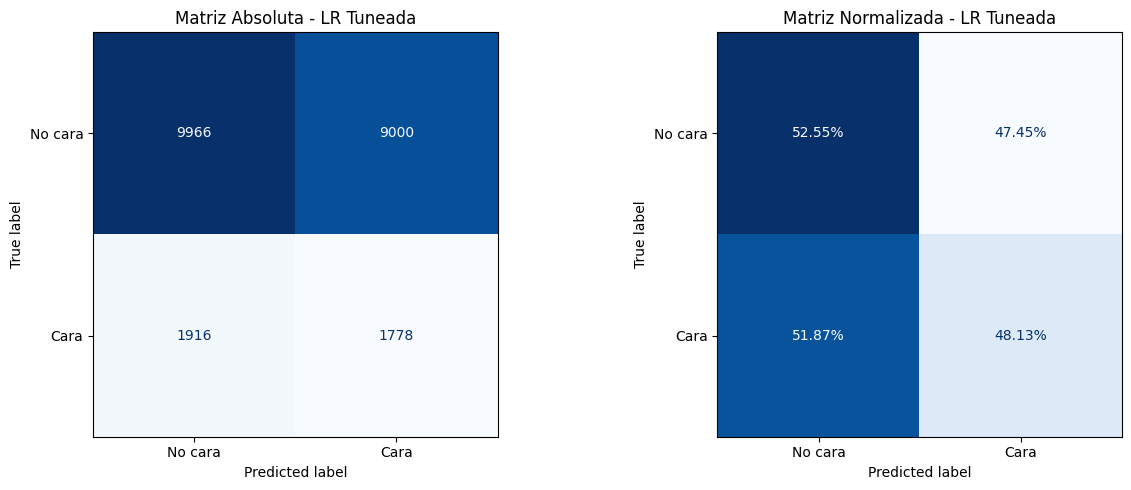

  Verdaderos Negativos (No cara correctos): 9966
  Falsos Positivos     (clasificadas cara sin serlo): 9000
  Falsos Negativos     (caras no detectadas): 1916
  Verdaderos Positivos (caras correctas): 1778


In [20]:
# Matriz de confusion del modelo tuneado
cm_tuned = confusion_matrix(y_test_cara, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm_tuned, display_labels=['No cara', 'Cara']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz Absoluta - LR Tuneada')

cm_tuned_norm = confusion_matrix(y_test_cara, y_pred_tuned, normalize='true')
ConfusionMatrixDisplay(cm_tuned_norm, display_labels=['No cara', 'Cara']).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='.2%')
axes[1].set_title('Matriz Normalizada - LR Tuneada')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_tuned.ravel()
print(f'  Verdaderos Negativos (No cara correctos): {tn}')
print(f'  Falsos Positivos     (clasificadas cara sin serlo): {fp}')
print(f'  Falsos Negativos     (caras no detectadas): {fn}')
print(f'  Verdaderos Positivos (caras correctas): {tp}')

In [21]:
# Profiling con cProfile
pr = cProfile.Profile()
pr.enable()
best_lr.fit(X_train_scaled, y_train_cara)
_ = best_lr.predict(X_test_scaled)
pr.disable()

s = io.StringIO()
ps = pstats.Stats(pr, stream=s).sort_stats('cumulative')
ps.print_stats(10)

print('PROFILING - Top 10 llamadas mas costosas ')
print(s.getvalue()[:1800])

PROFILING - Top 10 llamadas mas costosas 
         2676 function calls (2674 primitive calls) in 0.109 seconds

   Ordered by: cumulative time
   List reduced from 310 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3    0.000    0.000    0.109    0.036 C:\Users\irisa\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3665(run_code)
        3    0.000    0.000    0.109    0.036 {built-in method builtins.exec}
        1    0.000    0.000    0.108    0.108 c:\Users\irisa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1319(wrapper)
        1    0.000    0.000    0.107    0.107 c:\Users\irisa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1086(fit)
        1    0.098    0.098    0.102    0.102 c:\Users\irisa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1074(_fit_liblinear)
        2    0.000    

In [23]:
!pip install memory_profiler
from memory_profiler import memory_usage

# Memoria consumida
def entrenar_lr():
    m = LogisticRegression(**grid.best_params_, random_state=42, max_iter=1000)
    m.fit(X_train_scaled, y_train_cara)
    return m

mem_uso = memory_usage((entrenar_lr, ()), interval=0.1, max_iterations=1)
print(f'\n\nMemoria maxima durante entrenamiento: {max(mem_uso):.2f} MiB')
print(f'Memoria minima durante entrenamiento: {min(mem_uso):.2f} MiB')
print(f'Delta memoria: {max(mem_uso) - min(mem_uso):.2f} MiB')


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip




Memoria maxima durante entrenamiento: 291.43 MiB
Memoria minima durante entrenamiento: 285.90 MiB
Delta memoria: 5.53 MiB


#### Interpretacion

El modelo tuneado confirma el tradeoff esperado al aplicar class_weight='balanced': el accuracy baja de 83.70% a 51.83%, pero a cambio se recupera la capacidad de detectar la clase "Cara". El recall sube de 0.00 a 0.4813, lo que significa que el modelo ahora identifica correctamente al 48% de las propiedades caras, mientras que el modelo base no detectaba ninguna. La precision de 0.1650 indica que de cada 100 propiedades que el modelo predice como caras, solo 16 realmente lo son, mientras que la matriz de confusion muestra que de 3,694 propiedades caras reales el modelo acierta en 1,778 y falla en 1,916, y en el lado opuesto genera 9,000 falsos positivos (clasifica como caras propiedades que no lo son).

El ROC-AUC de 0.5060, practicamente igual al de un clasificador aleatorio, es la señal mas preocupante: indica que el modelo no esta discriminando realmente entre clases, sino que esencialmente esta lanzando una moneda ponderada por el class_weight. Esto sugiere que la relacion entre las variables predictoras y la categoria de precio no es linealmente separable, por lo que una regresion logistica (incluso regularizada y balanceada) tiene un techo de desempeño bajo en este dataset. La matriz normalizada refuerza esta lectura: las tasas de acierto en ambas clases rondan el 50%, que es justo lo que se esperaria del azar.

El profiling muestra que el entrenamiento completo consume apenas 0.109 segundos, siendo la funcion `_fit_liblinear` la que domina el tiempo (0.102s, un 94% del total). El resto de llamadas (validate_data, check_array, compute_class_weight) son marginales en tiempo. En cuanto a memoria, el delta durante el entrenamiento es de solo 5.53 MiB, lo que confirma que la regresion logistica es extremadamente eficiente en recursos para un dataset de 52,871 filas. Este sera el punto de comparacion clave contra Random Forest, que tipicamente consume ordenes de magnitud mas tiempo y memoria.

### Punto 9 – Seleccion del mejor modelo de Regresion Logistica

Se comparan los modelos generados (base sin tuneo y tuneado) usando AIC, BIC, metricas de la matriz de confusion y tiempo de entrenamiento. Para calcular AIC y BIC se usa statsmodels.

In [24]:
# AIC y BIC del modelo base (sin class_weight)
X_train_sm = sm.add_constant(X_train_scaled)
logit_base = sm.Logit(y_train_cara.values, X_train_sm).fit(disp=0)

print('MODELO BASE (sin class_weight)')
print(f'  AIC: {logit_base.aic:.2f}')
print(f'  BIC: {logit_base.bic:.2f}')
print(f'  Log-Likelihood: {logit_base.llf:.2f}')

MODELO BASE (sin class_weight)
  AIC: 60115.07
  BIC: 60301.46
  Log-Likelihood: -30036.54


In [25]:
# Tabla comparativa final
comparacion = pd.DataFrame({
    'Modelo'    : ['LR Base', 'LR Tuneada'],
    'Accuracy'  : [acc_test, acc_tuned],
    'Precision' : [precision_score(y_test_cara, y_pred_test, zero_division=0), precision_tuned],
    'Recall'    : [recall_score(y_test_cara, y_pred_test, zero_division=0), recall_tuned],
    'F1-Score'  : [f1_score(y_test_cara, y_pred_test, zero_division=0), f1_tuned],
    'ROC-AUC'   : [roc_auc_score(y_test_cara, y_prob_test), auc_tuned],
    'Tiempo (s)': [tiempo_lr, tiempo_tuneo],
    'AIC'       : [logit_base.aic, np.nan],
    'BIC'       : [logit_base.bic, np.nan]
})
print('COMPARACION DE MODELOS DE REGRESION LOGISTICA')
print(comparacion.to_string(index=False))

COMPARACION DE MODELOS DE REGRESION LOGISTICA
    Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Tiempo (s)          AIC          BIC
   LR Base  0.836981   0.000000 0.000000  0.000000 0.506248    0.020999 60115.070383 60301.458199
LR Tuneada  0.518270   0.164966 0.481321  0.245716 0.506025    3.235734          NaN          NaN


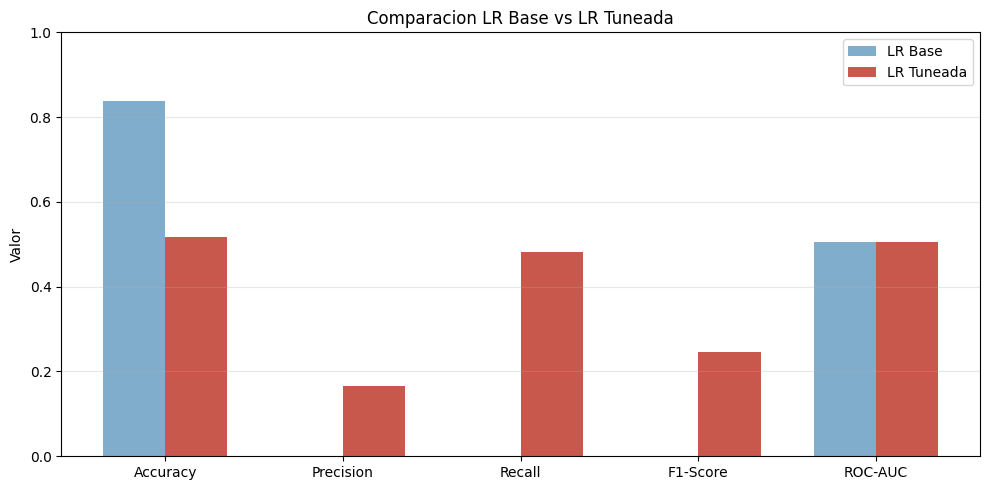


Mejor modelo seleccionado: LR Tuneada
Variables predictoras: 20


In [26]:
# Grafica comparativa
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
base_vals  = [acc_test, precision_score(y_test_cara, y_pred_test, zero_division=0),
              recall_score(y_test_cara, y_pred_test, zero_division=0),
              f1_score(y_test_cara, y_pred_test, zero_division=0),
              roc_auc_score(y_test_cara, y_prob_test)]
tuned_vals = [acc_tuned, precision_tuned, recall_tuned, f1_tuned, auc_tuned]

x = np.arange(len(metricas))
w = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - w/2, base_vals,  w, label='LR Base',    color='#80adcb')
plt.bar(x + w/2, tuned_vals, w, label='LR Tuneada', color='#c8584b')
plt.xticks(x, metricas)
plt.ylim(0, 1)
plt.ylabel('Valor')
plt.title('Comparacion LR Base vs LR Tuneada')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Guardar el mejor modelo para el punto 10
mejor_modelo_lr   = best_lr
variables_mejor   = X_train.columns.tolist()
print(f'\nMejor modelo seleccionado: LR Tuneada')
print(f'Variables predictoras: {len(variables_mejor)}')

#### Interpretacion

El modelo base presenta un AIC de 60,115.07 y un BIC de 60,301.46, con un log-likelihood de -30,036.54. Estos valores no son interpretables en terminos absolutos sino comparativos: serviran como linea base para evaluar si los modelos alternativos (Arbol, Random Forest, Naive Bayes, KNN) logran un mejor ajuste estadistico al dataset. Un AIC/BIC mas bajo indica mejor balance entre ajuste y complejidad del modelo. Cabe notar que el modelo tuneado no tiene AIC/BIC calculables via statsmodels porque sklearn no expone el log-likelihood directamente al aplicar class_weight='balanced', por eso aparecen como NaN en la tabla comparativa.

La comparacion entre LR Base y LR Tuneada evidencia el intercambio que se viene discutiendo a lo largo del laboratorio: el modelo base gana en accuracy (0.8370 vs 0.5183) pero pierde completamente en capacidad de clasificacion real, con precision, recall y F1-score iguales a 0.00 para la clase "Cara". El modelo tuneado, aunque baja en accuracy, es el unico que realmente clasifica: F1 de 0.2457 vs 0.0000, y un recall de 0.4813 que permite identificar casi la mitad de las propiedades caras. El ROC-AUC practicamente identico entre ambos (0.5062 vs 0.5060) es la señal mas contundente de que una regresion logistica, con o sin tuneo, tiene un techo de desempeño bajo en este problema: la frontera entre clases no es linealmente separable.

En terminos de tiempo, el modelo base se entreno en 0.02 segundos mientras que el tuneo completo tomo 3.24 segundos, un costo razonable considerando que explora 20 configuraciones con validacion cruzada de 5 folds. Para efectos de la comparacion contra los modelos no lineales, se selecciona la **LR Tuneada** como mejor modelo de regresion logistica porque es el unico que produce una clasificacion util desde el punto de vista del negocio de SmartStay: permite identificar propiedades caras, aunque con precision baja. Las 20 variables predictoras usadas seran las mismas empleadas en los modelos de Arbol, Random Forest, Naive Bayes y KNN para garantizar una comparacion justa.